![NVIDIA Logo](images/nvidia.png)

# Custom Passthrough Stage

In this notebook you'll learn how to write basic custom Morpheus stages using the Python SDK.

![stage](images/stage.png)

---

## Objectives

By the time you complete this notebook you will be able to:

- Build a custom passthrough stage.
- Understand the key components in custom stage definitions.
- Explain the role of MRC in the construction of inner-stage compute graphs.
- Utilize a custom stage in a pipeline.

---

## Imports

The following imports are used in this notebook. We will look at each of them individually as they are used in code.

In [1]:
import typing
import logging

from IPython.display import Image

from morpheus.config import Config
from morpheus.pipeline import LinearPipeline

from morpheus.stages.input.file_source_stage import FileSourceStage
from morpheus.stages.output.in_memory_sink_stage import InMemorySinkStage

from morpheus.pipeline.execution_mode_mixins import GpuAndCpuMixin
from morpheus.pipeline.pass_thru_type_mixin import PassThruTypeMixin
from morpheus.pipeline.single_port_stage import SinglePortStage

from morpheus.cli.register_stage import register_stage

from morpheus.utils.logger import configure_logging, reset_logging

import mrc
from mrc.core import operators as ops

## A Custom Passthrough Stage

Below is a class-based definition of a custom Morpheus stage. The stage is a no-op passthrough stage, meaning, it will receive messages, do nothing to them, and just send them out for the next stage in the pipeline.

In [2]:
@register_stage("pass-thru")
class PassThruStage(PassThruTypeMixin, GpuAndCpuMixin, SinglePortStage):
    """A Simple Pass Through Stage"""

    @property
    def name(self) -> str:
        return "pass-thru"

    def accepted_types(self) -> tuple:
        return (typing.Any, )

    def supports_cpp_node(self) -> bool:
        return False

    def on_data(self, message: typing.Any) -> typing.Any:
        return message

    def _build_single(self, builder: mrc.Builder, input_node: mrc.SegmentObject) -> mrc.SegmentObject:
        node = builder.make_node(self.unique_name, ops.map(self.on_data))
        builder.make_edge(input_node, node)

        return node

Let's look at the constituent parts of this custom stage definition before looking to use it in a pipeline.

---

## Register the Stage for CLI Usage

```python
@register_stage("pass-thru")
```

In [3]:
!morpheus --log_level=DEBUG run pipeline-fil from-file --filename="./data/simple_user_log.jsonlines"\
pass-thru to-file --filename="./data/output/output.jsonlines"

Configuring Pipeline via CLI
Usage: morpheus run pipeline-fil [OPTIONS] COMMAND1 [ARGS]... [COMMAND2
                                 [ARGS]...]...
Try 'morpheus run pipeline-fil --help' for help.

Error: No such command 'pass-thru'.


Using the `register_stage` decorator is not required, but doing so allows you to register a name for the custom stage for use with the Morpheus CLI. We won't be working with the CLI in this workshop, however, we wanted to point out this common convention.

---

In [4]:
config = Config()
a = PassThruStage(config)
a.name

'pass-thru'

## Stage Name

```python
@property
def name(self) -> str:
    return "pass-thru"
```

Custom stages need a calculated property `name` which returns a string name of the custom stage. By convention it tends to be the same as what is used with the `register_stage` decorator (if it is being used), but you are not constrained to do that.

The name is what you will see in many Morpheus outputs, including in logs and pipeline visualizations.

---

## Accepted Types

```python
def accepted_types(self) -> tuple:
    return (typing.Any, )
```

The `accepted_types` method returns a tuple of the types of messages that the stage is able to receive. As we mentioned earlier, Morpheus stages communicate with messages, and are strongly typed in terms of what type of messages they can receive and send.

In this example we are specifying that the stage can accept messages of any kind. In practice we tend to be more specific, and will be later in the workshop.

---

## CPP Implementation

```python
def supports_cpp_node(self) -> bool:
    return False
```

The `supports_cpp_node` method returns a boolean indicating if the stage has a C++ implementation. Since our example only contains a Python implementation we will return `False` here.

---

## Main Message Processing Method

```python
def on_data(self, message: typing.Any) -> typing.Any:
    return message
```

The `on_data` method accepts an incoming message and returns a message. The returned message can be the same message instance that we received as our input or it could be a new message instance.

In this case `on_data` is simply returning the message it is passed as an argument.

The method is named `on_data` by convention, however, this is not an actual constraint.

Below you'll see how the `on_data` method is registered as a callback such that it will be invoked to process data when needed in an event-driven way.

---

## Wire the Stage to the Pipeline

In order to understand the next method required for custom stage creation, we need to go a little bit deeper into the anatomy of a stage in Morpheus.

### Ports

We have already discussed that stages receive and send messages, but more precisely, stages receive and send messages through input and output **ports** respectively.

Up until this point in time in the workshop we have only been working with linear pipelines, and to this end, the stages in the linear pipelines we have been working with all have only a single input port and a single output port. Later in the workshop when we start to work with non-linear pipelines, we will need to create and manage multiple input and/or output ports, depending on the specifics of how we want our stage to interact with other, and potentially multiple, stages when receiving or sending messages.

### Nodes and Edges

Inside of a stage are **nodes**, independent processing elements. Nodes communicate with each other via **edges**.

The most simple stage would send incoming messages from a single port over an edge to a single node which would then send the message over an edge to a single output port:

`input-port -> processing-node -> output-port`

However, stages can be far more complicated, consisting of many processing nodes and edges, if so desired.

What we see then in Morpheus is a kind of "graphs inside of a graph" paradigm, where a pipeline itself is a computational graph, consisting of nodes called "stages" and where each stage is its own computational graph, consisting of its own processing nodes and edges.

![anatomy-of-a-stage](images/anatomy-of-a-stage.png)

---

## Building a Stage Graph with MRC

Morpheus uses [MRC (Morpheus Runtime Core)](https://github.com/nv-morpheus/MRC/tree/ac64c4f00bc11314f2b86146ab56c4e78bfdebc0) under the hood to manage the nodes and edges used within its stages.

When defining custom stages we need to provide a `_build_single` method which will be utilizing MRC to create the stage's nodes and wire them into the pipeline.

```python
def _build_single(self, builder: mrc.Builder, input_node: mrc.SegmentObject) -> mrc.SegmentObject:
```

`_build_single` receives an instance of an MRC segment builder (`mrc.Builder`) along with an `input_node` of type `mrc.SegmentObject`. We will be using the builder instance to construct a node from our stage and connecting it to the Morpheus pipeline. The return type of `_build_single` is our newly constructed node allowing downstream nodes to attach to our node.

For our purposes, a Morpheus stage defines the input data type the stage will accept, the unit of work to be performed on that data, and the output data type. In contrast, each individual node or nodes comprising a stage’s unit of work are wired into the underlying MRC execution pipeline. To build the node, we will call the `make_node` method of the builder instance, passing it our `unique_name` property method and applying MRC’s map operator to the `on_data` method we defined above.

```python
        node = builder.make_node(self.unique_name, ops.map(self.on_data))
```

Next, we will define an edge connecting our new node to our parent node:

```python
        builder.make_edge(input_node, node)
```

Finally, we will return our new node.

```python
        return node
```

---

## Inherited Classes

Our custom class is inheriting from several different classes.

```python
class PassThruStage(PassThruTypeMixin, GpuAndCpuMixin, SinglePortStage):
```

### PassThruTypeMixin

The `PassThruTypeMixin` defines a `compute_schema` method for us. The `compute_schema` method returns the schema of the output message type. The `PassThruTypeMixin`, should be used anytime a stage receives and emits messages of the same type, even if it only accepts messages of a specific type and modifies the data, the data type remains the same. Had we not used the `PassThruTypeMixin`, we would have defined the `compute_schema` method as follows:

```python
from morpheus.pipeline.stage_schema import StageSchema

def compute_schema(self, schema: StageSchema):
    schema.output_schema.set_type(schema.input_type)
```

While the `compute_schema` method is simple enough to write, the real value of the `PassThruTypeMixin` presents itself for stages which can handle inputs from multiple upstream ports and emit messages on multiple output ports. However, for now we are dealing with single port stages which are the most common type.

In [5]:
Config()

Config(execution_mode=<ExecutionMode.GPU: 'GPU'>, debug=False, log_level=30, log_config_file=None, plugins=None, mode=<PipelineModes.OTHER: 'OTHER'>, _pipeline_batch_size=256, _model_max_batch_size=8, feature_length=256, num_threads=1, edge_buffer_size=128, class_labels=[], ae=None, fil=None, frozen=False)

### GpuAndCpuMixin

GpuAndCpuMixin is a mixin class designed to be added to stages that support both GPU and CPU execution modes. It provides methods and properties to handle DataFrame operations for both execution environments.

### SinglePortStage

Morpheus stages that contain a single input port and a single output port inherit from `SinglePortStage`.

When we begin constructing custom stages that utilize multiple input and/or output ports, we will not inheret from either of these base classes.

---

## Custom Stage Definition Revisited

Now that we've covered it in great depth, let's revist our custom passthrough stage definition along with some more concise comments to help consolidate all of the meaningful details.

In [6]:
# Register the stage with a name for potential use with the Morpheus CLI.
@register_stage("pass-thru")
# Return the same message type as received (`PassThruTypeMixin`)
# Support dataframe execution on CPU and GPU environments (`GpuAndCpuMixin`)
# Single input port and single output port (`SinglePortStage`)
class PassThruStage(PassThruTypeMixin, GpuAndCpuMixin, SinglePortStage):
    """A Simple Pass Through Stage"""

    # Stage name for use in logging etc.
    @property
    def name(self) -> str:
        return "pass-thru"

    # Accepted incoming message types.
    def accepted_types(self) -> tuple:
        return (typing.Any, )

    # Does stage have CPP implementation?
    def supports_cpp_node(self) -> bool:
        return False

    # Main message processing method.
    def on_data(self, message: typing.Any) -> typing.Any:
        return message

    # Use `builder` to create new node and attach to `input_node`
    def _build_single(self, builder: mrc.Builder, input_node: mrc.SegmentObject) -> mrc.SegmentObject:
        # Create the new node, which maps over incoming data using `self.on_data`.
        node = builder.make_node(self.unique_name, ops.map(self.on_data))
        # Connect the new `node` to the `input_node`
        builder.make_edge(input_node, node)

        # Return the new node.
        return node

---

## Pipeline Using Custom Passthrough Stage

With our custom stage defined, we can now build a pipeline that uses it. Here we build another simple pipeline, reading our small user authentication log data from source, sending the messages through our passthrough stage, and then dumping the data into an in-memory sink.

In [7]:
input_file = 'data/simple_user_log.jsonlines'

In [8]:
config = Config()

In [9]:
pipeline = LinearPipeline(config)

pipeline.set_source(FileSourceStage(config, filename=input_file, iterative=False))
# Use our custom stage
pipeline.add_stage(PassThruStage(config))
in_mem_sink = pipeline.add_stage(InMemorySinkStage(config))

In [10]:
pipeline.build()

In [11]:
viz_file = './pipeline_visualizations/custom_passthrough.png'
pipeline.visualize(viz_file)

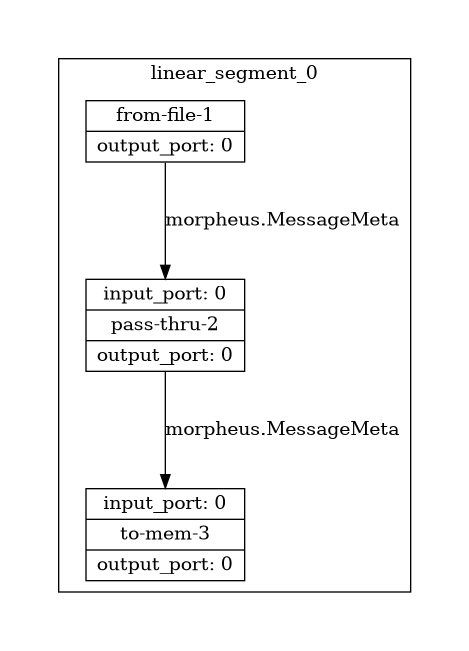

In [12]:
Image(filename=viz_file)

In [13]:
reset_logging()
configure_logging(log_level=logging.DEBUG)

====Starting Pipeline====
====Pipeline Started====
====Building Segment: linear_segment_0====
Added source: <from-file-1; FileSourceStage(filename=data/simple_user_log.jsonlines, iterative=False, file_type=FileTypes.Auto, repeat=1, filter_null=True, filter_null_columns=None, parser_kwargs=None)>
  └─> morpheus.MessageMeta
Added stage: <pass-thru-2; PassThruStage()>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta
Added stage: <to-mem-3; InMemorySinkStage()>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta
====Building Segment Complete!====
====Pipeline Complete====


In [14]:
await pipeline.run_async()

In [15]:
messages = in_mem_sink.get_messages()
messages[0].get_data()

,timestamp,user,ip_address,request_time,status,error_message
0,2025-02-01T10:15:30Z,user123,192.168.1.10,200.45,success,<NA>
1,2025-02-01T10:17:00Z,user123,192.168.1.20,150.55,failure,Invalid credentials
2,2025-02-01T10:18:10Z,user456,10.0.0.5,180.60,success,<NA>
3,2025-02-01T10:19:25Z,user789,192.168.1.30,215.25,failure,Timeout
4,2025-02-01T10:20:00Z,user456,10.0.0.6,120.10,success,<NA>
5,2025-02-01T10:22:30Z,user123,192.168.1.40,175.35,failure,Access denied
6,2025-02-01T10:23:45Z,user321,192.168.1.50,205.50,success,<NA>
7,2025-02-01T10:25:05Z,user864,192.168.1.60,190.15,failure,Invalid session
8,2025-02-01T10:26:20Z,user123,192.168.1.70,210.80,success,<NA>
9,2025-02-01T10:27:40Z,user456,10.0.0.7,160.95,failure,Account locked
